# Создание своего набора данных

## Парсер

In [2]:
import requests
import pandas as pd
import time

session = requests.Session()
session.trust_env = False

records = []
page = 0

print("Собираем данные через SteamSpy...")

while len(records) < 5500:
    resp = session.get(
        'https://steamspy.com/api.php',
        params={'request': 'all', 'page': page}
    )

    if resp.status_code != 200:
        print(f'Ошибка {resp.status_code} на странице {page}')
        break

    data = resp.json()
    if not data:
        print('Данные закончились')
        break

    for appid, g in data.items():
        total_reviews = g.get('positive', 0) + g.get('negative', 0)
        if total_reviews < 10:
            continue

        positive = g.get('positive', 0)
        ratio = positive / total_reviews if total_reviews > 0 else None


        if ratio is None:
            review_class = None
        elif ratio >= 0.8:
            review_class = 'Positive'
        else:
            review_class = 'Not Positive'

        records.append({
            'appid':           appid,
            'name':            g.get('name'),
            'developer':       g.get('developer'),
            'publisher':       g.get('publisher'),
            'price_usd':       (int(g.get('price') or 0)) / 100,
            'discount':        g.get('discount', 0),
            'genre':           g.get('genre', ''),
            'languages_count': len(g.get('languages', '').split(',')),
            'positive':        positive,
            'negative':        g.get('negative', 0),
            'total_reviews':   total_reviews,
            'review_ratio':    round(ratio, 4) if ratio else None,
            'avg_playtime':    g.get('average_forever', 0),
            'median_playtime': g.get('median_forever', 0),
            'peak_ccu':        g.get('ccu', 0),
            'review_class':    review_class,
        })

    print(f'  Страница {page} → собрано: {len(records)}')
    page += 1
    time.sleep(1)

df = pd.DataFrame(records).dropna(subset=['review_class'])
print(f'\nИтого: {len(df)} игр')
df.to_csv('steam_games.csv', index=False)
print('Сохранено → steam_games.csv')

Собираем данные через SteamSpy...
  Страница 0 → собрано: 998
  Страница 1 → собрано: 1992
  Страница 2 → собрано: 2979
  Страница 3 → собрано: 3959
  Страница 4 → собрано: 4939
  Страница 5 → собрано: 5903

Итого: 5903 игр
Сохранено → steam_games.csv


In [5]:
import time
import requests
import pandas as pd
from concurrent.futures import ThreadPoolExecutor, as_completed

session = requests.Session()
session.trust_env = False

def fetch_appdetails(appid):
    try:
        resp = requests.get(
            'https://steamspy.com/api.php',
            params={'request': 'appdetails', 'appid': appid},
            timeout=10
        )
        if resp.status_code != 200:
            return appid, {}
        return appid, resp.json()
    except:
        return appid, {}

def parse_extra(d):
    tags = d.get('tags', {})
    if isinstance(tags, dict) and tags:
        genre     = ', '.join(list(tags.keys())[:3])
        tag_count = len(tags)
    else:
        genre     = None
        tag_count = 0

    owners_str = d.get('owners', '0 .. 0')
    try:
        owners_min = int(owners_str.split('..')[0].strip().replace(',', ''))
    except:
        owners_min = 0

    return {
        'genre':              genre,
        'tag_count':          tag_count,
        'userscore':          d.get('userscore', 0),
        'owners_min':         owners_min,
        'avg_playtime_2w':    d.get('average_2weeks', 0),
        'median_playtime_2w': d.get('median_2weeks', 0),
    }

print(f"Обогащаем датасет... всего {len(df)} игр")

results = {}
completed = 0

with ThreadPoolExecutor(max_workers=8) as executor:
    futures = {executor.submit(fetch_appdetails, row['appid']): idx
               for idx, row in df.iterrows()}

    for future in as_completed(futures):
        appid, data = future.result()
        results[appid] = parse_extra(data)
        completed += 1
        if completed % 200 == 0:
            print(f"  {completed}/{len(df)} готово")

extra_data = [results[row['appid']] for _, row in df.iterrows()]
extra_df = pd.DataFrame(extra_data, index=df.index)

df = pd.concat([df.drop(columns=['genre'], errors='ignore'), extra_df], axis=1)
df.to_csv('steam_games.csv', index=False)
print(f"\nГотово! Итоговых столбцов: {df.shape[1]}")
print(df[['genre', 'tag_count', 'userscore', 'owners_min']].head())

Обогащаем датасет... всего 5903 игр
  200/5903 готово
  400/5903 готово
  600/5903 готово
  800/5903 готово
  1000/5903 готово
  1200/5903 готово
  1400/5903 готово
  1600/5903 готово
  1800/5903 готово
  2000/5903 готово
  2200/5903 готово
  2400/5903 готово
  2600/5903 готово
  2800/5903 готово
  3000/5903 готово
  3200/5903 готово
  3400/5903 готово
  3600/5903 готово
  3800/5903 готово
  4000/5903 готово
  4200/5903 готово
  4400/5903 готово
  4600/5903 готово
  4800/5903 готово
  5000/5903 готово
  5200/5903 готово
  5400/5903 готово
  5600/5903 готово
  5800/5903 готово

Готово! Итоговых столбцов: 21
                                      genre  tag_count  userscore  owners_min
0                 FPS, Shooter, Multiplayer         20          0   100000000
1  Free to Play, Battle Royale, Multiplayer         20          0   100000000
2          Survival, Shooter, Battle Royale         20          0   100000000
3  Open World, Survival, Creature Collector         20          0    50000

# Цели и правила разметки

Цель сбора датасета: предсказать, будет ли игра положительно оценена
пользователями Steam, на основе её характеристик.

Обоснование выбранных параметров (почему собирались именно они):

Целевая переменная:
- review_class → бинаризована: Positive (review_ratio >= 0.8) vs Not Positive
  Присутствует у всех игр с 10+ отзывами — ручная разметка не требуется.

Признаки:
- price_usd        — цена: платные игры требуют более высокого качества
- discount         — скидка: может отражать падение популярности
- languages_count  — количество языков: больше языков = шире аудитория
- total_reviews    — количество отзывов: популярность игры
- avg_playtime     — среднее время в игре: косвенная метрика качества
- median_playtime  — медианное время: устойчивее к выбросам
- peak_ccu         — пиковый онлайн: мера популярности
- developer        — разработчик: топ-студии стабильно делают хорошие игры
- price_per_review — цена / отзывы: соотношение цены и популярности
- is_free          — бесплатная ли игра

Правила сбора:
- Данные получены через публичный API SteamSpy без авторизации
- Собрано постранично: 1000 игр/страница, 6 страниц
- Исключены игры с менее чем 10 отзывами (ненадёжная разметка)
- Исключены записи без значения review_class

## Импорт библиотек

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings('ignore')

SEED = 42
print('Готово.')

Готово.


## Пример данных

Размер: 5903 строк × 21 столбцов



,appid,name,developer,publisher,price_usd,discount,languages_count,positive,negative,total_reviews,...,avg_playtime,median_playtime,peak_ccu,review_class,genre,tag_count,userscore,owners_min,avg_playtime_2w,median_playtime_2w
0,730,Counter-Strike: Global Offensive,Valve,Valve,0.00,0,1,7642084,1173003,8815087,...,0,0,1013936,Positive,"FPS, Shooter, Multiplayer",20,0,100000000,0,0
1,1172470,Apex Legends,Respawn,Electronic Arts,0.00,0,1,668053,326926,994979,...,0,0,124262,Not Positive,"Free to Play, Battle Royale, Multiplayer",20,0,100000000,0,0
2,578080,PUBG: BATTLEGROUNDS,PUBG Corporation,"KRAFTON, Inc.",0.00,0,1,1520457,1037487,2557944,...,0,0,314682,Not Positive,"Survival, Shooter, Battle Royale",20,0,100000000,0,0
3,1623730,Palworld,Pocketpair,Pocketpair,29.99,0,1,358266,22443,380709,...,0,0,18028,Positive,"Open World, Survival, Creature Collector",20,0,50000000,0,0
4,440,Team Fortress 2,Valve,Valve,0.00,0,1,1044264,117208,1161472,...,0,0,43819,Positive,"Free to Play, Hero Shooter, Multiplayer",20,0,50000000,0,0



Пропуски:
appid                  0
name                   0
developer             21
publisher             28
price_usd              0
discount               0
languages_count        0
positive               0
negative               0
total_reviews          0
review_ratio           0
avg_playtime           0
median_playtime        0
peak_ccu               0
review_class           0
genre                  0
tag_count              0
userscore              0
owners_min             0
avg_playtime_2w        0
median_playtime_2w     0
dtype: int64

Распределение классов:
review_class
Positive        3604
Not Positive    2299
Name: count, dtype: int64

Топ-10 жанров:
genre
Sexual Content, Nudity, Mature              23
Free to Play, Massively Multiplayer, RPG    16
Racing, Automobile Sim, Simulation          15
Casual, Indie, Puzzle                       14
Action, FPS, Shooter                        13
Puzzle, Casual, Indie                       13
Action, FPS, Multiplayer                  

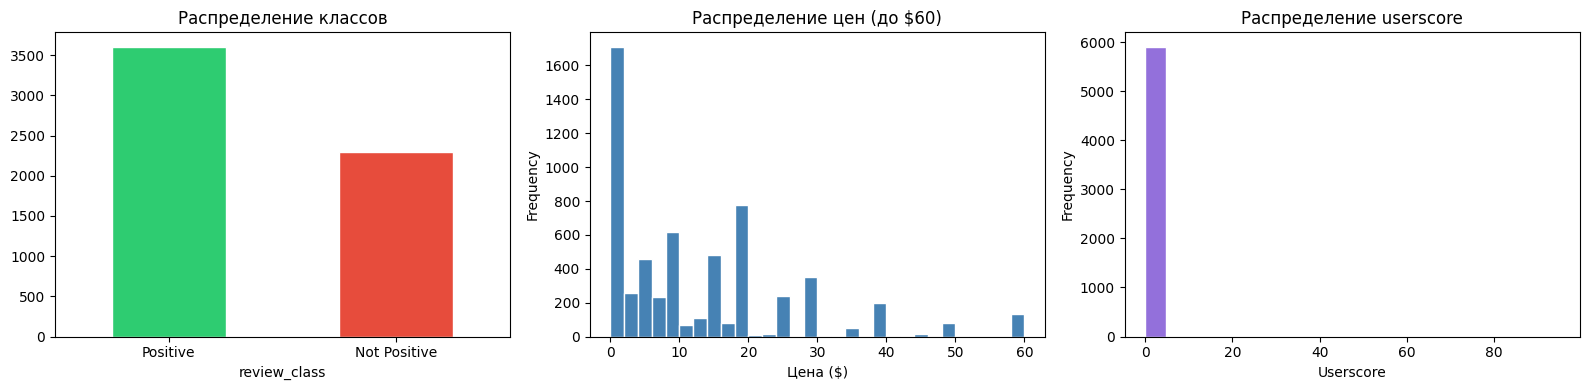

Userscore > 0 у 1 игр из 5903 — признак исключён из модели


In [15]:
df = pd.read_csv('steam_games.csv')

print(f'Размер: {df.shape[0]} строк × {df.shape[1]} столбцов\n')
display(df.head())

print('\nПропуски:')
print(df.isnull().sum())

print('\nРаспределение классов:')
print(df['review_class'].value_counts())

print('\nТоп-10 жанров:')
print(df['genre'].value_counts().head(10))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df['review_class'].value_counts().plot.bar(
    ax=axes[0], color=['#2ecc71', '#e74c3c'], edgecolor='white'
)
axes[0].set_title('Распределение классов')
axes[0].tick_params(axis='x', rotation=0)

df['price_usd'].clip(0, 60).plot.hist(
    ax=axes[1], bins=30, color='steelblue', edgecolor='white'
)
axes[1].set_title('Распределение цен (до $60)')
axes[1].set_xlabel('Цена ($)')

df['userscore'].plot.hist(
    ax=axes[2], bins=20, color='mediumpurple', edgecolor='white'
)
axes[2].set_title('Распределение userscore')
axes[2].set_xlabel('Userscore')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=120)
plt.show()
print(f"Userscore > 0 у {(df['userscore'] > 0).sum()} игр из {len(df)} — признак исключён из модели")

## Baseline

Train: 4722  |  Test: 1181

Accuracy:      0.715
F1 (weighted): 0.707

              precision    recall  f1-score   support

Not Positive       0.67      0.53      0.59       460
    Positive       0.74      0.83      0.78       721

    accuracy                           0.71      1181
   macro avg       0.70      0.68      0.69      1181
weighted avg       0.71      0.71      0.71      1181



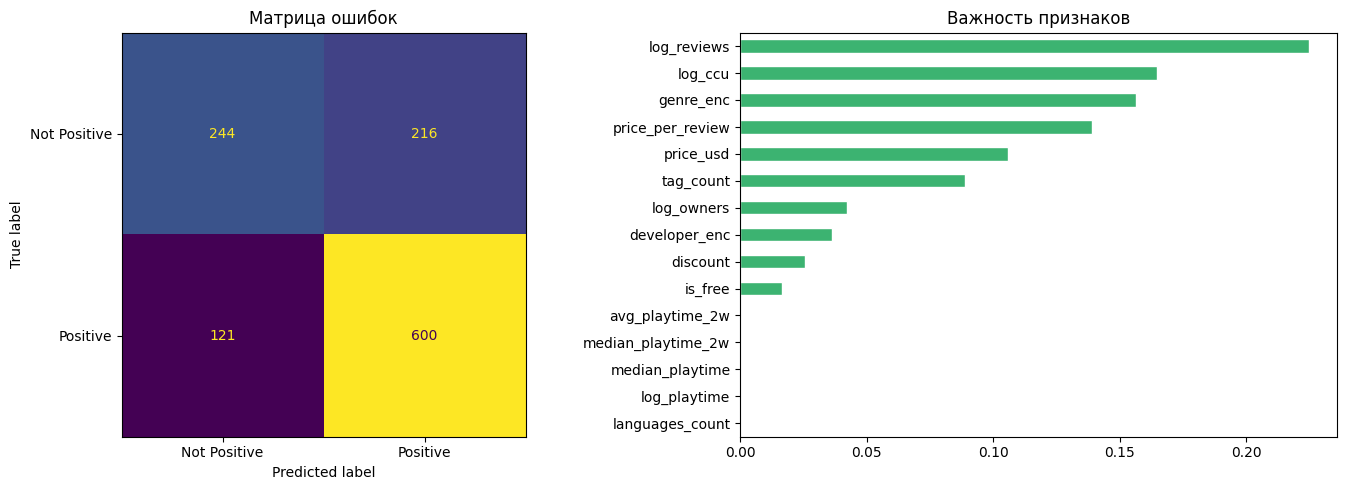

In [16]:
df_model = df.dropna(subset=['review_class']).copy()
df_model['target'] = (df_model['review_class'] == 'Positive').astype(int)

top_devs = df_model['developer'].value_counts().head(100).index
df_model['developer_enc'] = df_model['developer'].apply(
    lambda x: x if x in top_devs else 'other'
)

enc_dev = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
df_model[['developer_enc']] = enc_dev.fit_transform(df_model[['developer_enc']])

enc_genre = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
df_model['genre'] = df_model['genre'].fillna('unknown')
df_model[['genre_enc']] = enc_genre.fit_transform(df_model[['genre']])

df_model['log_reviews']      = np.log1p(df_model['total_reviews'])
df_model['log_ccu']          = np.log1p(df_model['peak_ccu'])
df_model['log_playtime']     = np.log1p(df_model['avg_playtime'])
df_model['log_owners']       = np.log1p(df_model['owners_min'])
df_model['price_per_review'] = df_model['price_usd'] / (df_model['total_reviews'] + 1)
df_model['is_free']          = (df_model['price_usd'] == 0).astype(int)

FEATURES = [
    'price_usd', 'discount', 'languages_count',
    'log_reviews', 'log_ccu', 'log_playtime',
    'median_playtime', 'developer_enc', 'genre_enc',
    'price_per_review', 'is_free', 'tag_count',
    'log_owners', 'avg_playtime_2w', 'median_playtime_2w'
]

df_model[FEATURES] = df_model[FEATURES].fillna(-1)
y = df_model['target']

X_train, X_test, y_train, y_test = train_test_split(
    df_model[FEATURES], y, test_size=0.2, random_state=SEED, stratify=y
)
print(f'Train: {len(X_train)}  |  Test: {len(X_test)}')

clf = RandomForestClassifier(
    n_estimators=300, max_depth=15,
    min_samples_leaf=2, random_state=SEED, n_jobs=-1
)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(f'\nAccuracy:      {accuracy_score(y_test, y_pred):.3f}')
print(f'F1 (weighted): {f1_score(y_test, y_pred, average="weighted"):.3f}')
print()
print(classification_report(y_test, y_pred, target_names=['Not Positive', 'Positive']))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=['Not Positive', 'Positive'],
    ax=axes[0], colorbar=False
)
axes[0].set_title('Матрица ошибок')

pd.Series(clf.feature_importances_, index=FEATURES).sort_values().plot.barh(
    ax=axes[1], color='mediumseagreen', edgecolor='white'
)
axes[1].set_title('Важность признаков')
plt.tight_layout()
plt.savefig('baseline_results.png', dpi=120)
plt.show()

## Как использовать датасет

Собранный массив данных предоставляет основу для задачи бинарной классификации:
предсказание положительной оценки игры пользователями Steam.

Работа с датасетом предполагает прохождение нескольких этапов:

Этап 1: Загрузка
df = pd.read_csv('steam_games.csv')

Этап 2: Предобработка
Создать бинарную целевую переменную (review_class == 'Positive'),
закодировать разработчика через OrdinalEncoder (топ-100 + 'other'),
добавить log-преобразования для признаков с большим разбросом (total_reviews, peak_ccu).

Этап 3: Обучение и оценка
Разделить данные 80/20, обучить RandomForestClassifier,
оценить качество по Accuracy и F1-score (weighted).

Структура файла steam_games.csv:
- appid           : уникальный ID игры в Steam
- name            : название игры
- developer       : разработчик
- publisher       : издатель
- price_usd       : цена в долларах
- discount        : текущая скидка (%)
- languages_count : количество поддерживаемых языков
- positive        : количество положительных отзывов
- negative        : количество отрицательных отзывов
- total_reviews   : общее количество отзывов
- review_ratio    : доля положительных отзывов (0.0–1.0)
- avg_playtime    : среднее время игры (минуты)
- median_playtime : медианное время игры (минуты)
- peak_ccu        : пиковый онлайн
- review_class    : ЦЕЛЕВАЯ ПЕРЕМЕННАЯ (Positive / Not Positive)